#Imporitng libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use("default")
sns.set_theme(style="whitegrid")

#Dataset

##Load the dataset

In [ ]:
#load the dataset
df = pd.read_csv("creditcard.csv")

##Dataset understanding & profiling

In [ ]:
#dataset shape
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

#dataset info
df.info()

#missing values
print(df.isnull().sum())

#dupicate values
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed successfully.")
else:
    print("No duplicate rows found.")
print(f"Dataset Shape: {df.shape}")
assert df.isnull().sum().sum() == 0, "Dataset contains missing values!"
print("\nData quality check completed successfully.")


Rows    : 284,807
Columns : 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

#Stratified sampling (to reduce data size)

In [ ]:
df_sample = (
    df.groupby("Class", group_keys=False)
      .apply(lambda x: x.sample(frac=0.1, random_state=42))
      .reset_index(drop=True)
)

print(f"Original size : {len(df):,} rows")
print(f"Sampled size  : {len(df_sample):,} rows")

print("\nClass Distribution:")
print(df_sample["Class"].value_counts())

print(f"\nFraud % in original : {df['Class'].mean()*100:.4f}%")
print(f"Fraud % in sample   : {df_sample['Class'].mean()*100:.4f}%")

# Use sampled data for the remaining analysis
df = df_sample.copy()

Original size : 283,726 rows
Sampled size  : 28,372 rows

Class Distribution:
Class
0    28325
1       47
Name: count, dtype: int64

Fraud % in original : 0.1667%
Fraud % in sample   : 0.1657%


In [ ]:
df["Hour"] = (df["Time"] // 3600).astype(int) % 24
df["Is_night"] = ((df["Hour"] >= 22) | (df["Hour"] <= 5)).astype(int)

#Exploratory Data Analysis (EDA)

##Class distribution analysis


=== Class Distribution ===
Legitimate (0): 28,325 (99.83%)
Fraudulent  (1): 47 (0.17%)


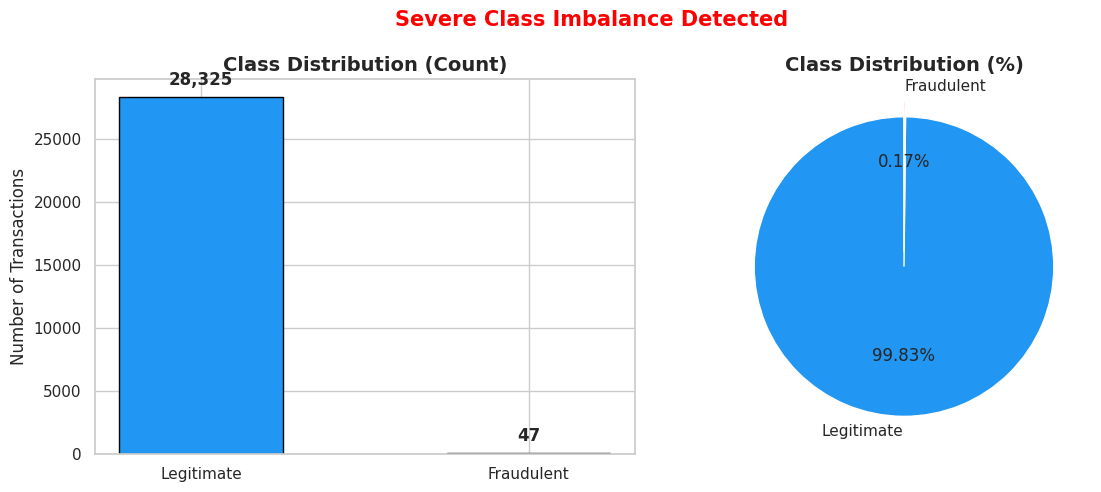

Chart saved as class_imbalance.png


In [ ]:
# Class distribution analysis
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
print(f'Legitimate (0): {class_counts[0]:,} ({class_pct[0]:.2f}%)')
print(f'Fraudulent  (1): {class_counts[1]:,} ({class_pct[1]:.2f}%)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.2f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Severe Class Imbalance Detected', fontsize=15, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as class_imbalance.png')

##Transactional amount analysis

In [ ]:
#transactional amount analysis
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

print(f'Total rows     : {len(df):,}')
print(f'Fraud rows     : {len(fraud):,}')
print(f'Legitimate rows: {len(legit):,}')
print(f'\nAmount Statistics:')
print(f'Avg Legitimate : ${legit.mean():.2f}')
print(f'Avg Fraud      : ${fraud.mean():.2f}')
print(f'Max Legitimate : ${legit.max():.2f}')
print(f'Max Fraud      : ${fraud.max():.2f}')

Total rows     : 28,372
Fraud rows     : 47
Legitimate rows: 28,325

Amount Statistics:
Avg Legitimate : $88.24
Avg Fraud      : $104.27
Max Legitimate : $7712.43
Max Fraud      : $730.86


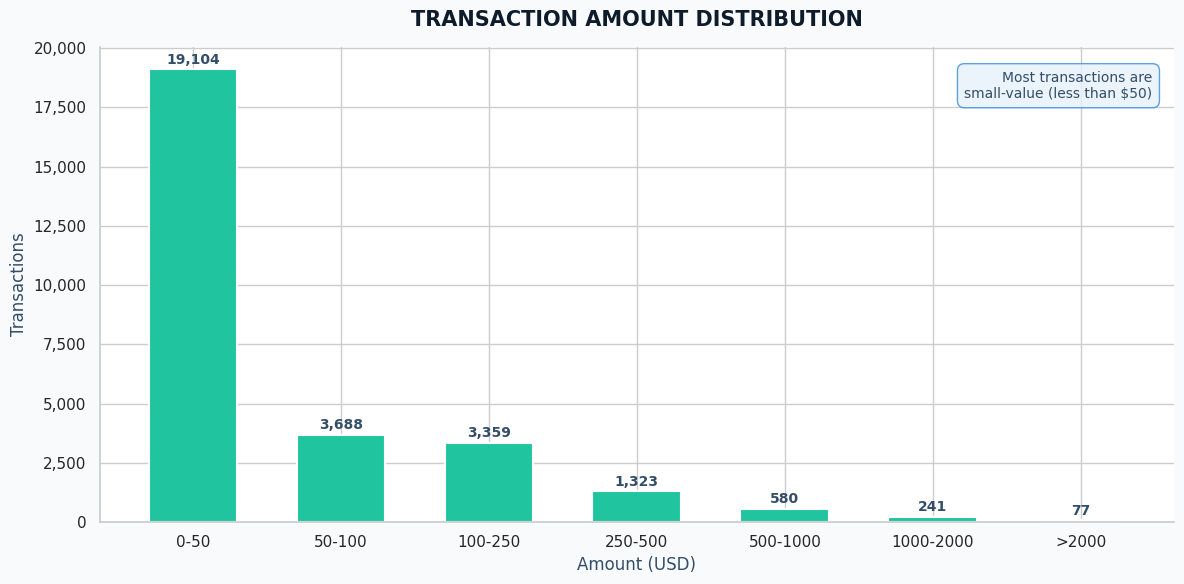

Saved: amount_bucket_distribution.png


In [ ]:
# CHART 1: Amount Bucket Distribution

# Create buckets
bins   = [-0.01, 50, 100, 250, 500, 1000, 2000, np.inf]
labels = ['0-50', '50-100', '100-250', '250-500',
          '500-1000', '1000-2000', '>2000']

df['Amount_Bucket'] = pd.cut(df['Amount'], bins=bins, labels=labels)
bucket_counts = df['Amount_Bucket'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#FFFFFF')

bars = ax.bar(
    labels, bucket_counts.values,
    color='#20C5A0',
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Data labels on bars
for bar, val in zip(bars, bucket_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{int(val):,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#334E68'
    )

ax.set_title('TRANSACTION AMOUNT DISTRIBUTION',
             fontsize=15, fontweight='bold',
             color='#0D1B2A', pad=15)
ax.set_xlabel('Amount (USD)', fontsize=12, color='#334E68')
ax.set_ylabel('Transactions', fontsize=12, color='#334E68')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.spines[['top','right']].set_visible(False)

# Insight text box
ax.text(0.98, 0.95,
        'Most transactions are\nsmall-value (less than $50)',
        transform=ax.transAxes,
        fontsize=10, color='#334E68',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='#E6F1FB',
                  edgecolor='#378ADD',
                  alpha=0.8))

plt.tight_layout()
plt.savefig('amount_bucket_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('Saved: amount_bucket_distribution.png')

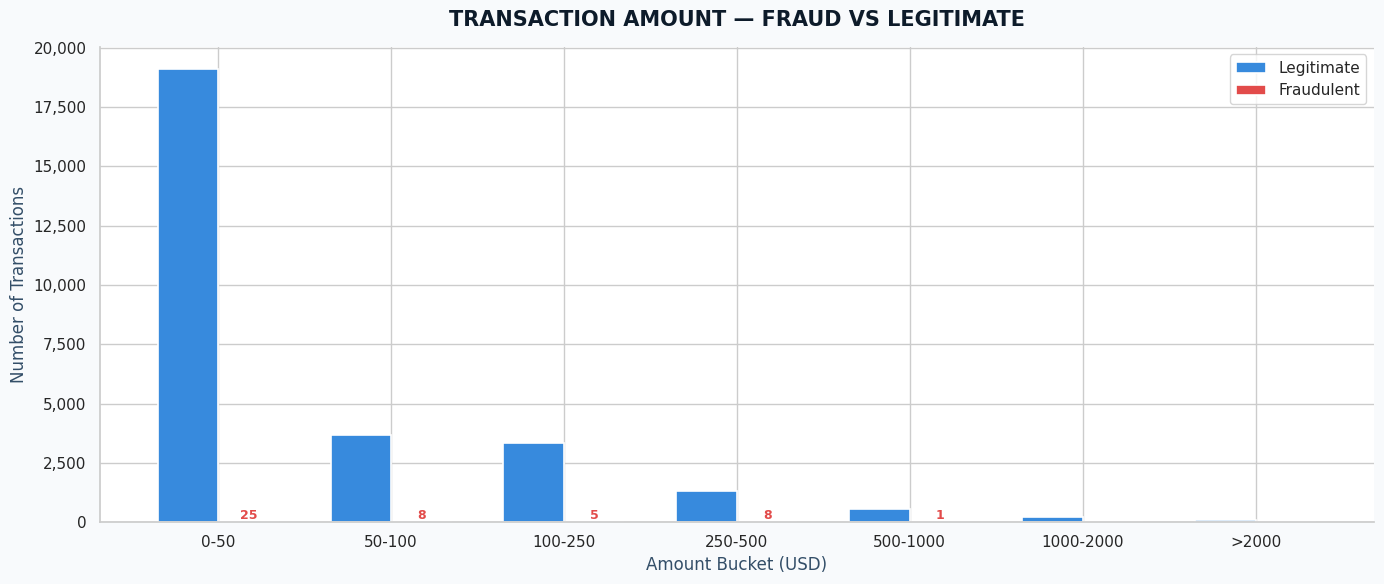

Saved: amount_fraud_vs_legit.png


In [ ]:
#CHART 2: Fraud vs Legitimate Amount Comparison

fraud_buckets = pd.cut(fraud, bins=bins, labels=labels).value_counts().reindex(labels)
legit_buckets = pd.cut(legit, bins=bins, labels=labels).value_counts().reindex(labels)

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#FFFFFF')

bars1 = ax.bar(x - width/2, legit_buckets.values,
               width, label='Legitimate',
               color='#378ADD', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, fraud_buckets.values,
               width, label='Fraudulent',
               color='#E24B4A', edgecolor='white', linewidth=1.2)

# Data labels
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{int(bar.get_height())}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#E24B4A')

ax.set_title('TRANSACTION AMOUNT — FRAUD VS LEGITIMATE',
             fontsize=15, fontweight='bold',
             color='#0D1B2A', pad=15)
ax.set_xlabel('Amount Bucket (USD)', fontsize=12, color='#334E68')
ax.set_ylabel('Number of Transactions', fontsize=12, color='#334E68')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('amount_fraud_vs_legit.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('Saved: amount_fraud_vs_legit.png')

## Transaction Time Analysis

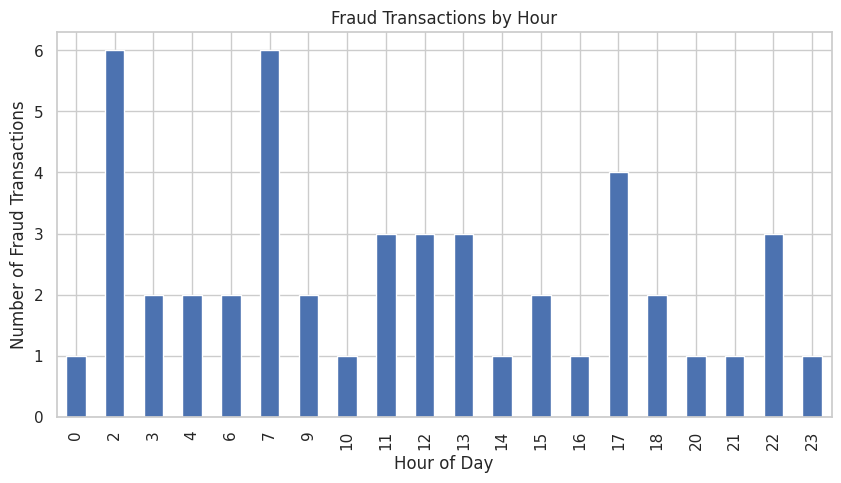

In [ ]:
#CHART 1 : fraud transactions by hour


fraud_hour = (
    df[df['Class'] == 1]
    .groupby('Hour')
    .size()
)

plt.figure(figsize=(10,5))

fraud_hour.plot(kind='bar')

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Transactions")

plt.show()

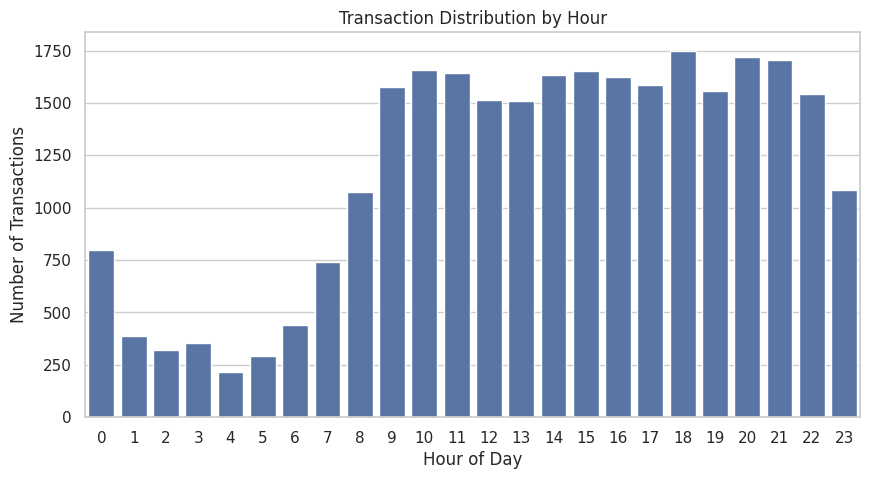

In [ ]:
# CHART 2 : transaction distribution by hour
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Hour'
)

plt.title("Transaction Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

## Day vs Night Transaction Analysis

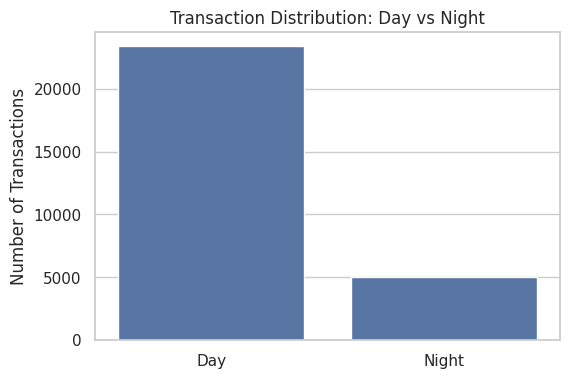

In [ ]:
# CHART 1 : transaction distribution
day_night_counts = df['Is_night'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(
    x=['Day', 'Night'],
    y=day_night_counts.values
)

plt.title("Transaction Distribution: Day vs Night")
plt.ylabel("Number of Transactions")
plt.show()

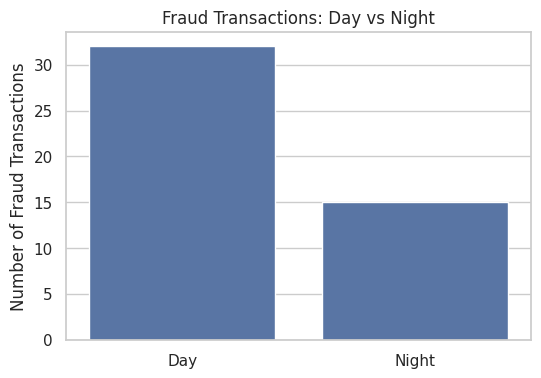

In [ ]:
# CHART 2 : fraud transaction
fraud_day_night = df[df['Class'] == 1]['Is_night'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(
    x=['Day', 'Night'],
    y=fraud_day_night.values
)

plt.title("Fraud Transactions: Day vs Night")
plt.ylabel("Number of Fraud Transactions")
plt.show()

In [ ]:
# summary
summary = df.groupby('Is_night')['Class'].agg(
    Total_Transactions='count',
    Fraud_Transactions='sum'
)

summary.index = ['Day', 'Night']

print(summary)

       Total_Transactions  Fraud_Transactions
Day                 23378                  32
Night                4994                  15


## Correlation Analysis

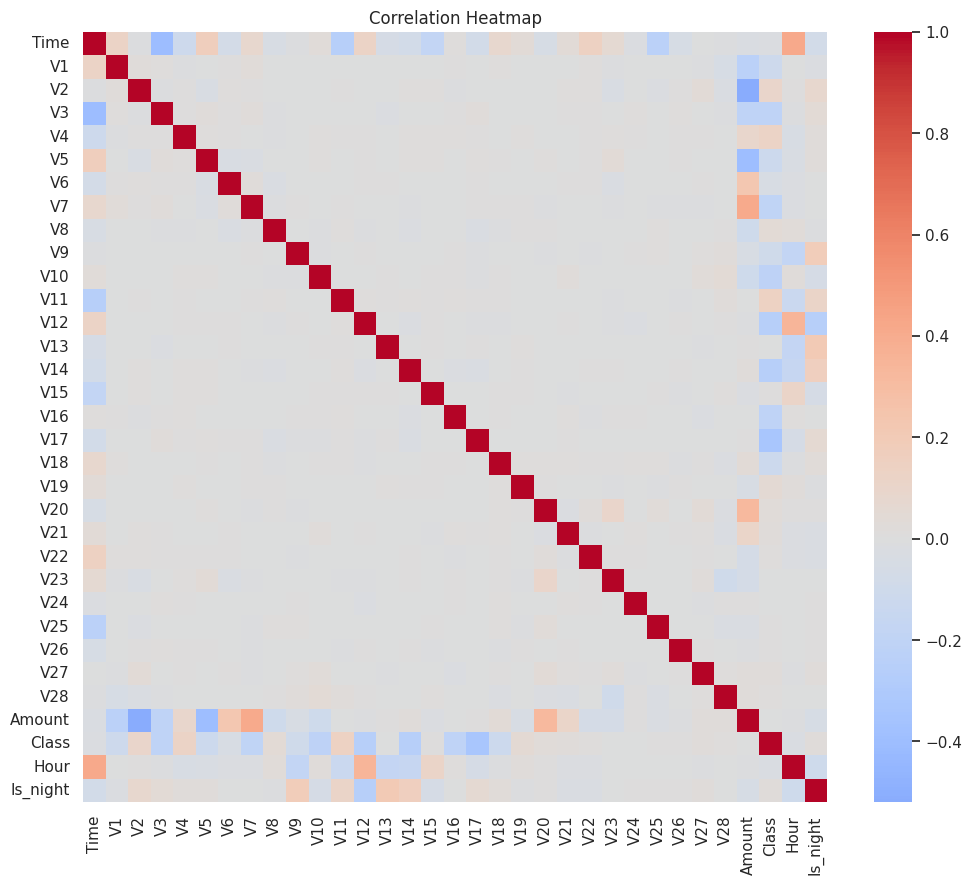

,Class
V17,-0.337094
V14,-0.254896
V12,-0.246671
V10,-0.211482
V3,-0.203281
V16,-0.202521
V7,-0.198666
V11,0.137595
V18,-0.121421
V5,-0.119833


In [ ]:
# Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Features most correlated with fraud
corr_matrix["Class"].drop("Class").sort_values(key=abs, ascending=False).head(10)

## PCA Feature Analysis

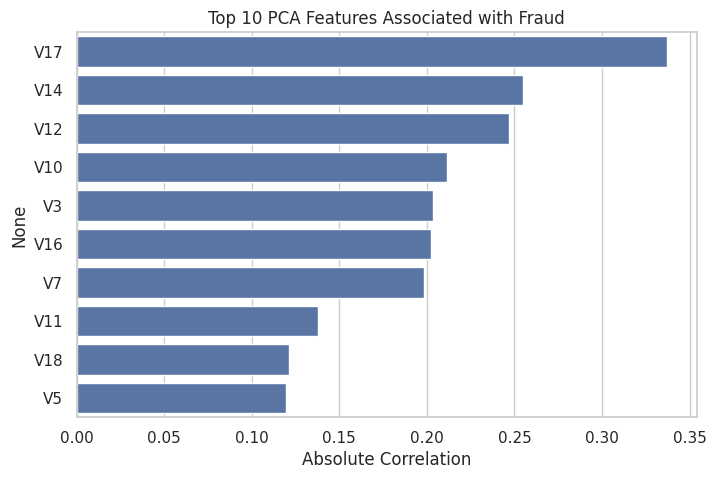

,Class
V17,0.337094
V14,0.254896
V12,0.246671
V10,0.211482
V3,0.203281
V16,0.202521
V7,0.198666
V11,0.137595
V18,0.121421
V5,0.119833


In [ ]:
# Correlation of PCA features with fraud
pca_corr = df[[f"V{i}" for i in range(1, 29)] + ["Class"]].corr()["Class"].drop("Class")

# Top 10 most influential PCA features
top_features = pca_corr.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 PCA Features Associated with Fraud")
plt.xlabel("Absolute Correlation")
plt.show()

# Display top correlated features
top_features

#Feature Engineering

##Engineered features

In [ ]:
df["Amount_log"] = np.log1p(df["Amount"])

print("Feature engineering completed successfully!")

print("\nEngineered Features:")
print("- Hour")
print("- Is_night")
print("- Amount_log")

# Preview original and engineered features
df[["Time", "Hour", "Amount", "Amount_log", "Is_night"]].head()

Feature engineering completed successfully!

Engineered Features:
- Hour
- Is_night
- Amount_log


,Time,Hour,Amount,Amount_log,Is_night
0,166238.0,22,2.58,1.275363,1
1,62888.0,17,11.04,2.488234,0
2,40687.0,11,1.78,1.022451,0
3,101450.0,4,157.29,5.064429,1
4,55862.0,15,34.12,3.558771,0


##Outlier analysis

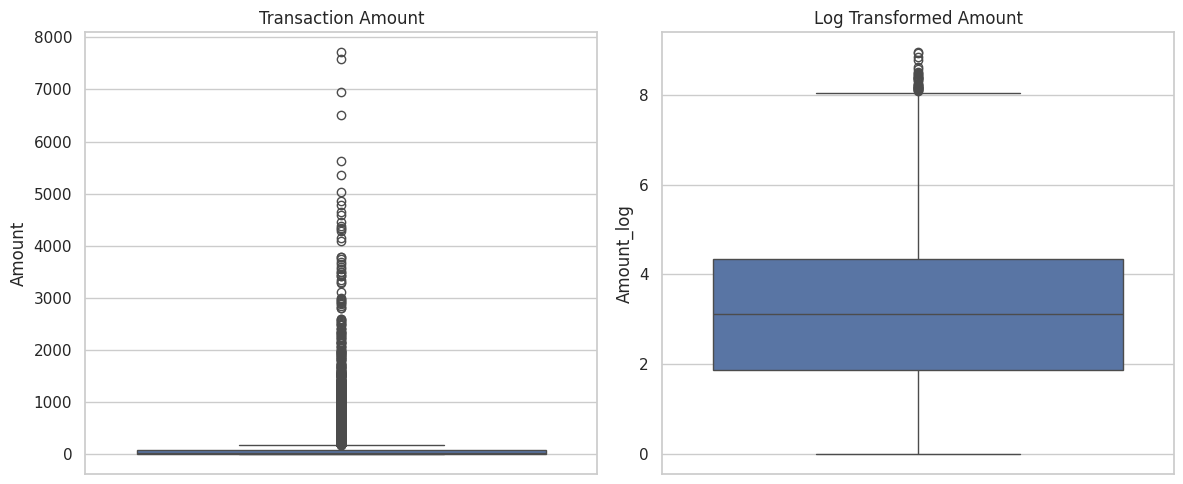

Number of Outliers: 3188
Outliers: 3188 (11.24%)


In [ ]:
# Boxplots for outlier detection
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Amount"])
plt.title("Transaction Amount")

plt.subplot(1,2,2)
sns.boxplot(y=df["Amount_log"])
plt.title("Log Transformed Amount")

plt.tight_layout()
plt.show()

# IQR-based outlier count
Q1, Q3 = df["Amount"].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df[
    (df["Amount"] < Q1 - 1.5*IQR) |
    (df["Amount"] > Q3 + 1.5*IQR)
]
print("Number of Outliers:", len(outliers))
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

#Model training

##model training

In [ ]:
# Features and target
X = df.drop(columns=["Class", "Time", "Amount_Bucket"])
y = df["Class"]

# Scale amount-related features
scaler = StandardScaler()
X[["Amount", "Amount_log"]] = scaler.fit_transform(
    X[["Amount", "Amount_log"]]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

Training samples : 22,697
Testing samples  : 5,675


##Logistic regression

In [ ]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


##Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


##Model evaluation

In [ ]:
# Make predictions and probability predictions for Logistic Regression
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Make predictions and probability predictions for Random Forest
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1 Score","ROC AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred),
        roc_auc_score(y_test, lr_prob)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.965639,0.999471
1,Precision,0.039604,1.000000
2,Recall,0.888889,0.666667
3,F1 Score,0.075829,0.800000
4,ROC AUC,0.989597,0.885673


##creating other dashboard columns

In [44]:
# Model predictions
df["Predicted_Class"] = lr_model.predict(X)
df["Fraud_Probability"] = lr_model.predict_proba(X)[:, 1]

# Transaction type
df["Transaction_Type"] = df["Class"].map({
    0: "Legitimate",
    1: "Fraudulent"
})

# Risk level
df["Risk_Level"] = pd.cut(
    df["Fraud_Probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print("Dashboard features created successfully!")



Dashboard features created successfully!


##Risk level analysis

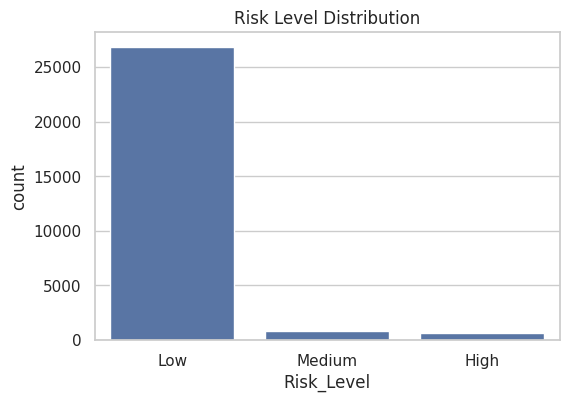

,count
Risk_Level,
Low,26859
Medium,853
High,660


In [46]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Risk_Level", order=["Low","Medium","High"])

plt.title("Risk Level Distribution")

plt.show()

df["Risk_Level"].value_counts()

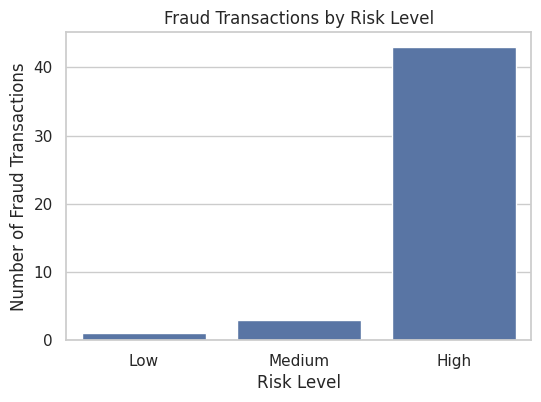

In [ ]:
fraud_risk = df[df['Class'] == 1]['Risk_Level'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(
    x=fraud_risk.index,
    y=fraud_risk.values
)

plt.title("Fraud Transactions by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Fraud Transactions")
plt.show()

In [ ]:

fraud_risk = df[df['Class'] == 1]['Risk_Level'].value_counts()

print("Top Risk Levels for Fraud:")
print(fraud_risk)



Top Risk Levels for Fraud:
Risk_Level
High      43
Medium     3
Low        1
Name: count, dtype: int64


#Export the processed data

In [ ]:
df.to_csv("processed_dataset.csv", index=False)

print("Processed dataset exported successfully.")

Processed dataset exported successfully.
